In [2]:
!pip install langchain langchain-classic flashrank langchain_google_genai jsonref

In [3]:
pip install -U google-genai langchain-google-genai ragas

In [4]:
!pip install langchain langchain-community langchain-openai langchain-experimental chromadb flashrank ragas datasets pypdf tiktoken sentence-transformers langchain-huggingface

In [14]:
!pip install -qU langchain-cohere cohere

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.0/43.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 334.3/334.3 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 9.9 MB/s eta 0:00:00


In [11]:
# Cell 2: Imports and Security
import os
import time
import pandas as pd
from getpass import getpass

# LangChain & Ingestion Imports
from langchain_community.document_loaders import PyPDFLoader
from langchain_experimental.text_splitter import SemanticChunker
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_community.document_compressors import FlashrankRerank
from langchain_classic.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

# Gemini & RAGAS Imports
from langchain_google_genai import ChatGoogleGenerativeAI
from google import genai
from datasets import Dataset
from ragas import evaluate
from ragas.run_config import RunConfig
from ragas.llms import llm_factory
from ragas.metrics import faithfulness, answer_relevancy, context_precision

# Securely set the API Key
print("Enter your Google Gemini API Key:")
GEMINI_KEY = getpass()
os.environ["GOOGLE_API_KEY"] = GEMINI_KEY

/tmp/ipykernel_3558/2023200800.py:25: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, answer_relevancy, context_precision
/tmp/ipykernel_3558/2023200800.py:25: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import faithfulness, answer_relevancy, context_precision
/tmp/ipykernel_3558/2023200800.py:25: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision
  from ragas.metrics import faithfulness, answer_relevancy, context

Enter your Google Gemini API Key:
··········


In [7]:
# Cell 3: Ingestion and Chunking
print("Loading embeddings and processing PDF...")
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

loader = PyPDFLoader("Company-Policy-and-Procedure-June-1.18-V6.0.pdf")
docs = loader.load()

semantic_splitter = SemanticChunker(embeddings, breakpoint_threshold_type="percentile")
semantic_chunks = semantic_splitter.split_documents(docs)

print(f"✅ Generated {len(semantic_chunks)} Semantic Chunks.")

Loading embeddings and processing PDF...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Generated 215 Semantic Chunks.


In [8]:
# Cell 4: Vector Search and Reranking
print("Building ChromaDB and FlashRank Retriever...")
vectorstore = Chroma.from_documents(
    documents=semantic_chunks,
    embedding=embeddings,
    persist_directory="./policy_memory_db"
)

base_retriever = vectorstore.as_retriever(search_kwargs={"k": 10})
compressor = FlashrankRerank(top_n=3)

rerank_retriever = ContextualCompressionRetriever(
    base_compressor=compressor,
    base_retriever=base_retriever
)
print("✅ Retriever pipeline ready.")

Building ChromaDB and FlashRank Retriever...


ms-marco-MultiBERT-L-12.zip: 100%|██████████| 98.7M/98.7M [00:00<00:00, 198MiB/s]


✅ Retriever pipeline ready.


In [18]:
# Cell 5: The RAG Chain (Cohere)
import os
from getpass import getpass
from langchain_cohere import ChatCohere
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

# Using the active, non-deprecated model version
llm = ChatCohere(model="command-r-08-2024", temperature=0)

template = """You are a strict company policy librarian.
Answer the question ONLY using the provided Context.

RULES:
1. If the answer is not in the Context, say "I'm sorry, that information is not in the policy."
2. Do not use outside info.

Context: {context}

Question: {question}

Answer:"""

prompt = PromptTemplate.from_template(template)

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

rag_chain = (
    {"context": rerank_retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)
print("✅ Cohere Generator pipeline ready.")

✅ Cohere Generator pipeline ready.


In [22]:
# ==========================================
# PHASE 1: GENERATE AND SAVE TO FILE
# ==========================================
import json

test_data = [
    {"question": "Who is the Chair and CEO of TriageLogic?", "reference": "Charu G. Raheja, PhD is the Chair and CEO of TriageLogic."},
    {"question": "What is the average call back time according to the Key Features?", "reference": "The average call back time is less than 30 minutes."},
    {"question": "How long must audio records be kept by TriageLogic?", "reference": "Audio records will be kept for a period of 3 months."},
    {"question": "Who has the final approval authority for all marketing and sales communications?", "reference": "The Marketing Committee has the final approval authority for all marketing and sales communications for the company."},
    {"question": "What is the acceptable performance standard score for the end-user satisfaction survey?", "reference": "An average score of 3.8 or above overall satisfaction was used as the acceptable performance standard."},
    {"question": "Within what time frame should corrective actions be completed after identifying a problem during an internal investigation?", "reference": "Corrective action should be completed within 30 business days."},
    {"question": "How often are TriageLogic marketing and sales communication materials reviewed by the Marketing Committee?", "reference": "All marketing and sales communication materials will be reviewed at least annually."},
    {"question": "Are users of the TriageLogic system required to print information based on standard workflows?", "reference": "All users of the system are NEVER required to print any information based on standard workflows. Users are NOT PERMITTED to print any information."},
    {"question": "How does TriageLogic define 'Plain Language'?", "reference": "Plain Language is defined as: Communication that uses short words and sentences, common terms instead of (medical) jargon, and focuses on the essential information recipients need to understand."},
    {"question": "What is the procedure if both the primary and backup servers are unavailable?", "reference": "The triage system will go into emergency mode, which includes sending an email to nursing staff to handle calls manually, contacting other nurse managers, and directing non-clinical staff to use a fax number."}
]

print("🚀 PHASE 1: Cohere Generation...")
generated_data = []

for i, item in enumerate(test_data):
    q = item["question"]
    print(f"Generating answer {i+1}/10...")

    retrieved_docs = rerank_retriever.invoke(q)
    context_list = [doc.page_content for doc in retrieved_docs]
    answer = rag_chain.invoke(q)

    generated_data.append({
        "question": q,
        "answer": answer,
        "contexts": context_list,
        "reference": item["reference"]
    })

# Save to disk!
with open("phase1_cache.json", "w", encoding="utf-8") as f:
    json.dump(generated_data, f, ensure_ascii=False, indent=4)

print("\n💾 PHASE 1 SAVED! You can now freely run and debug Phase 2 without regenerating.")

🚀 PHASE 1: Cohere Generation...
Generating answer 1/10...
Generating answer 2/10...
Generating answer 3/10...
Generating answer 4/10...
Generating answer 5/10...
Generating answer 6/10...
Generating answer 7/10...
Generating answer 8/10...
Generating answer 9/10...
Generating answer 10/10...

💾 PHASE 1 SAVED! You can now freely run and debug Phase 2 without regenerating.


In [26]:
# ==========================================
# PHASE 2: LOAD AND EVALUATE
# ==========================================
import json
import time
import warnings
import pandas as pd
from datasets import Dataset
from ragas import evaluate
from ragas.run_config import RunConfig
from ragas.llms import LangchainLLMWrapper
from langchain_cohere import ChatCohere
from langchain_community.embeddings import HuggingFaceEmbeddings

# -> FIX 1: Hide the annoying deprecation warnings from Ragas
warnings.filterwarnings("ignore", category=DeprecationWarning)

# -> FIX 2: Revert to the old metric paths which still accept LangchainLLMWrapper
from ragas.metrics import Faithfulness, AnswerRelevancy, ContextPrecision

# 1. Load the pre-generated data from disk
print("📂 Loading Phase 1 data from disk...")
with open("phase1_cache.json", "r", encoding="utf-8") as f:
    generated_data = json.load(f)

# 2. Setup Cohere Judge
cohere_judge = ChatCohere(model="command-r-08-2024", temperature=0.0, max_tokens=4000)

# Override the RAGAS finish_reason checker so it accepts Cohere's "COMPLETE" flag
ragas_llm = LangchainLLMWrapper(
    cohere_judge,
    is_finished_parser=lambda response: True
)

eval_embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

# Initialize the metric objects properly
f_metric = Faithfulness(llm=ragas_llm)
r_metric = AnswerRelevancy(llm=ragas_llm, embeddings=eval_embeddings)
p_metric = ContextPrecision(llm=ragas_llm)

# 3. The Evaluation Loop
print("\n🚀 PHASE 2: Cohere Evaluation...")
final_results = []
fast_config = RunConfig(max_workers=2, timeout=120)

for i, data in enumerate(generated_data):
    print(f"Evaluating Question {i+1}/{len(generated_data)}...")

    single_dataset = Dataset.from_dict({
        "question": [data["question"]],
        "answer": [data["answer"]],
        "contexts": [data["contexts"]],
        "reference": [data["reference"]]
    })

    try:
        # Pass the initialized metric objects
        res = evaluate(
            single_dataset,
            metrics=[f_metric, r_metric, p_metric],
            llm=ragas_llm,
            run_config=fast_config
        )

        row = res.to_pandas().iloc[0].to_dict()
        final_results.append({
            'question': data["question"],
            'faithfulness': row.get('faithfulness', float('nan')),
            'answer_relevancy': row.get('answer_relevancy', float('nan')),
            'context_precision': row.get('context_precision', float('nan'))
        })

        print(f"✅ F: {final_results[-1]['faithfulness']:.2f} | R: {final_results[-1]['answer_relevancy']:.2f} | P: {final_results[-1]['context_precision']:.2f}")

    except Exception as e:
        print(f"❌ Error: {e}")

    time.sleep(1)

# 4. Final Output
final_df = pd.DataFrame(final_results)
final_df.to_csv("rag_cohere_evaluation_results.csv", index=False)
print("\n🎉 EVALUATION COMPLETE! Saved to 'rag_cohere_evaluation_results.csv'")
print("\n--- AVERAGE SCORES ---")
print(final_df.mean(numeric_only=True))

📂 Loading Phase 1 data from disk...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



🚀 PHASE 2: Cohere Evaluation...
Evaluating Question 1/10...


Evaluating:   0%|          | 0/3 [00:00<?, ?it/s]

...

✅ F: 1.00 | R: 0.28 | P: 1.00
Evaluating Question 9/10...


Evaluating:   0%|          | 0/3 [00:00<?, ?it/s]

✅ F: 1.00 | R: 0.21 | P: 1.00
Evaluating Question 10/10...


Evaluating:   0%|          | 0/3 [00:00<?, ?it/s]

✅ F: 0.80 | R: 0.91 | P: 1.00

🎉 EVALUATION COMPLETE! Saved to 'rag_cohere_evaluation_results.csv'

--- AVERAGE SCORES ---
faithfulness         0.780000
answer_relevancy     0.538027
context_precision    0.850000
dtype: float64


/tmp/ipykernel_3558/2613758276.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=averages.index, y=averages.values, palette="viridis")


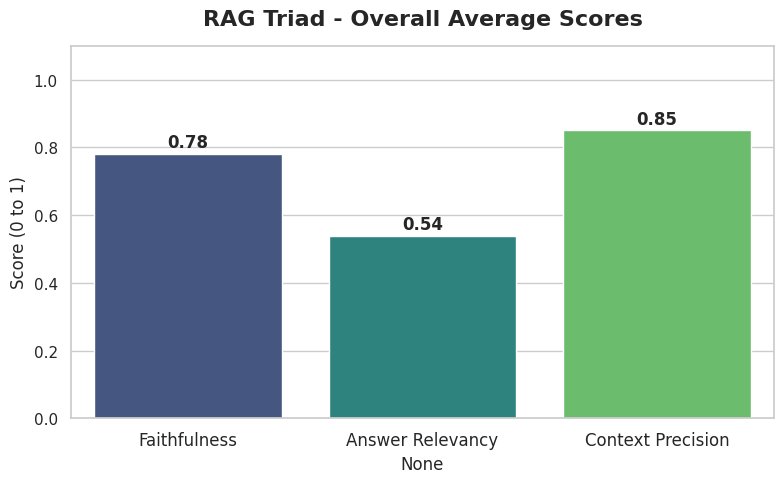

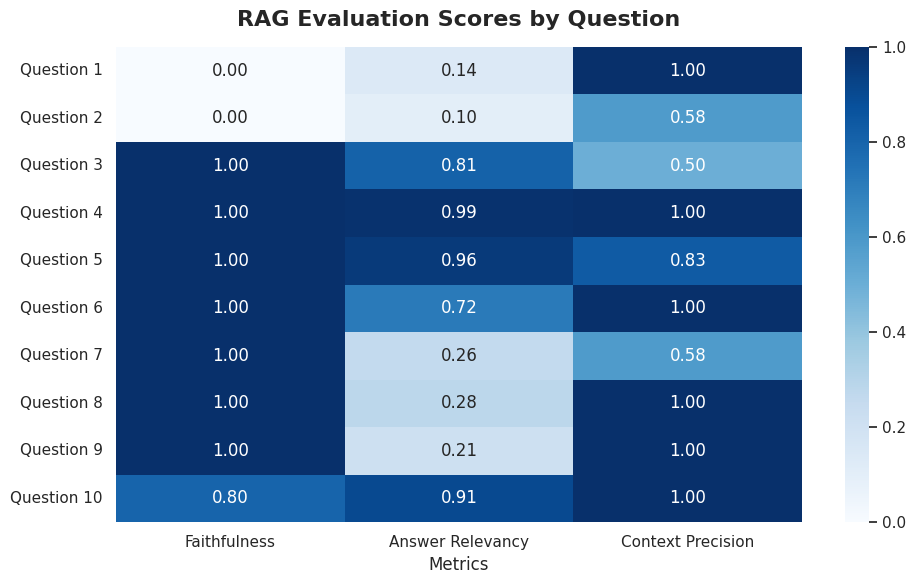

✅ Visualizations generated and saved as 'rag_averages_chart.png' and 'rag_heatmap_chart.png'!


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Evaluation Results
df = pd.read_csv("rag_cohere_evaluation_results.csv")
averages = df[['faithfulness', 'answer_relevancy', 'context_precision']].mean()

# Set up the visual style
sns.set_theme(style="whitegrid")

# ==========================================
# CHART 1: Average Scores Bar Chart
# ==========================================
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=averages.index, y=averages.values, palette="viridis")

plt.title('RAG Triad - Overall Average Scores', fontsize=16, fontweight='bold', pad=15)
plt.ylim(0, 1.1) # Set Y-axis from 0 to 1
plt.ylabel('Score (0 to 1)', fontsize=12)
plt.xticks(ticks=[0, 1, 2], labels=['Faithfulness', 'Answer Relevancy', 'Context Precision'], fontsize=12)

# Add the exact numbers on top of the bars
for i, v in enumerate(averages.values):
    ax.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('rag_averages_chart.png', dpi=300) # Saves a high-res image for your Notion/GitHub!
plt.show()

# ==========================================
# CHART 2: Question-by-Question Heatmap
# ==========================================
plt.figure(figsize=(10, 6))
heatmap_data = df[['faithfulness', 'answer_relevancy', 'context_precision']]

sns.heatmap(heatmap_data, annot=True, cmap='Blues', vmin=0, vmax=1, fmt=".2f",
            yticklabels=[f"Question {i+1}" for i in range(len(df))])

plt.title('RAG Evaluation Scores by Question', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Metrics', fontsize=12)
plt.xticks(ticks=[0.5, 1.5, 2.5], labels=['Faithfulness', 'Answer Relevancy', 'Context Precision'])

plt.tight_layout()
plt.savefig('rag_heatmap_chart.png', dpi=300) # Saves a high-res image for your Notion/GitHub!
plt.show()

print("✅ Visualizations generated and saved as 'rag_averages_chart.png' and 'rag_heatmap_chart.png'!")